In [12]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [13]:
from pathlib import Path

# Path setup (relative to this notebook file) 
notebook_path = Path("plotting.ipynb").resolve()
script_dir = notebook_path.parent 
csv_folder = script_dir / "Auto_Logged_Data_March27_PD"

print("Notebook dir:", script_dir)
print("CSV folder:", csv_folder)

Notebook dir: C:\Users\home\Desktop\ACC\Auto-Cruise\Adaptive-Cruise-Control\Adaptive-Cruise-Control\9_Vehicle_Testing_Results\Testing_Using_Radar\March27_2026
CSV folder: C:\Users\home\Desktop\ACC\Auto-Cruise\Adaptive-Cruise-Control\Adaptive-Cruise-Control\9_Vehicle_Testing_Results\Testing_Using_Radar\March27_2026\Auto_Logged_Data_March27_PD


In [14]:
# choose files to plot (all CSVs in the folder)
selected_files = sorted([p.name for p in csv_folder.glob("*.csv")])
print("Selected files:")
for f in selected_files:
    print(f)


Selected files:
Data_Mar27_PD_10kph_CS1.csv
Data_Mar27_PD_10kph_CS2.csv
Data_Mar27_PD_10kph_CS3.csv
Data_Mar27_PD_5kph_CS3.csv
Data_Mar27_PD_CS1_5kmph.csv
Data_Mar27_PD_CS2_5kmph.csv


In [15]:
data = {}
for file in selected_files:
    path = os.path.join(csv_folder, file)
    df = pd.read_csv(path)

    # Check if DataFrame is empty or missing required columns
    if df.empty:
        print(f"Skipping {file}: empty DataFrame")
        continue
    if "Time(s)" not in df.columns:
        print(f"Skipping {file}: missing 'Time(s)' column")
        continue

    
    # normalize time for this file
    df["Time"] = df["Time(s)"] - df["Time(s)"].iloc[0]
    # Clip garbage velocity values (greater than 10 m/s) to 0
    df["Ego_Velocity(m/s)"] = df["Ego_Velocity(m/s)"].apply(lambda x: x if x < 10 else 0)
    if "Obs_Velocity(m/s)" in df.columns:
        df["Obs_Velocity(m/s)"] = df["Obs_Velocity(m/s)"].apply(lambda x: x if x > 0 and x < 5.6 else 0)
    
    # Calculate acceleration from velocity (simple finite difference)
    df["Ego_Acceleration(m/s^2)"] = df["Ego_Velocity(m/s)"].diff() / df["Time"].diff()
    if "Obs_Velocity(m/s)" in df.columns:
        df["Obs_Acceleration(m/s^2)"] = df["Obs_Velocity(m/s)"].diff() / df["Time"].diff()
        
    # convert to km/h 
    df["Ego_Velocity_kmph"] = df["Ego_Velocity(m/s)"] * 3.6
    if "Obs_Velocity(m/s)" in df.columns:
        df["Obs_Velocity_kmph"] = df["Obs_Velocity(m/s)"] * 3.6

    data[file] = df

    print(file, "loaded")
    display(df.head())

Data_Mar27_PD_10kph_CS1.csv loaded


,Ego_Position(m),Ego_Velocity(m/s),Obs_Position(m),Obs_Velocity(m/s),Separation(m),Relative velocity(m/s),Time(s),Time,Ego_Acceleration(m/s^2),Obs_Acceleration(m/s^2),Ego_Velocity_kmph,Obs_Velocity_kmph
0,0.0,0.0,NaN,0.0,NaN,NaN,0.000007,0.000000,NaN,NaN,0.0,0.0
1,0.0,0.0,NaN,0.0,NaN,NaN,7.729965,7.729958,0.0,0.0,0.0,0.0
2,0.0,0.0,NaN,0.0,NaN,NaN,7.840417,7.840410,0.0,0.0,0.0,0.0
3,0.0,0.0,NaN,0.0,NaN,NaN,7.950040,7.950033,0.0,0.0,0.0,0.0
4,0.0,0.0,NaN,0.0,NaN,NaN,8.059573,8.059566,0.0,0.0,0.0,0.0


Data_Mar27_PD_10kph_CS2.csv loaded


,Ego_Position(m),Ego_Velocity(m/s),Obs_Position(m),Obs_Velocity(m/s),Separation(m),Relative velocity(m/s),Time(s),Time,Ego_Acceleration(m/s^2),Obs_Acceleration(m/s^2),Ego_Velocity_kmph,Obs_Velocity_kmph
0,0.0,0.0,NaN,0.0,NaN,NaN,0.000006,0.000000,NaN,NaN,0.0,0.0
1,0.0,0.0,NaN,0.0,NaN,NaN,8.429897,8.429891,0.0,0.0,0.0,0.0
2,0.0,0.0,NaN,0.0,NaN,NaN,8.538747,8.538741,0.0,0.0,0.0,0.0
3,0.0,0.0,NaN,0.0,NaN,NaN,8.650843,8.650836,0.0,0.0,0.0,0.0
4,0.0,0.0,NaN,0.0,NaN,NaN,8.758709,8.758703,0.0,0.0,0.0,0.0


Data_Mar27_PD_10kph_CS3.csv loaded


...

,Ego_Position(m),Ego_Velocity(m/s),Obs_Position(m),Obs_Velocity(m/s),Separation(m),Relative velocity(m/s),Time(s),Time,Ego_Acceleration(m/s^2),Obs_Acceleration(m/s^2),Ego_Velocity_kmph,Obs_Velocity_kmph
0,0.0,0.0,NaN,0.0,NaN,NaN,0.000010,0.000000,NaN,NaN,0.0,0.0
1,0.0,0.0,NaN,0.0,NaN,NaN,7.255471,7.255461,0.0,0.0,0.0,0.0
2,0.0,0.0,NaN,0.0,NaN,NaN,7.365489,7.365479,0.0,0.0,0.0,0.0
3,0.0,0.0,NaN,0.0,NaN,NaN,7.475413,7.475403,0.0,0.0,0.0,0.0
4,0.0,0.0,NaN,0.0,NaN,NaN,7.585775,7.585765,0.0,0.0,0.0,0.0


Data_Mar27_PD_CS1_5kmph.csv loaded


,Ego_Position(m),Ego_Velocity(m/s),Obs_Position(m),Obs_Velocity(m/s),Separation(m),Relative velocity(m/s),Time(s),Time,Ego_Acceleration(m/s^2),Obs_Acceleration(m/s^2),Ego_Velocity_kmph,Obs_Velocity_kmph
0,0.0,0.0,NaN,0.0,NaN,NaN,0.000012,0.000000,NaN,NaN,0.0,0.0
1,0.0,0.0,NaN,0.0,NaN,NaN,7.614126,7.614115,0.0,0.0,0.0,0.0
2,0.0,0.0,NaN,0.0,NaN,NaN,7.723658,7.723647,0.0,0.0,0.0,0.0
3,0.0,0.0,NaN,0.0,NaN,NaN,7.832845,7.832833,0.0,0.0,0.0,0.0
4,0.0,0.0,NaN,0.0,NaN,NaN,7.943047,7.943035,0.0,0.0,0.0,0.0


Data_Mar27_PD_CS2_5kmph.csv loaded


,Ego_Position(m),Ego_Velocity(m/s),Obs_Position(m),Obs_Velocity(m/s),Separation(m),Relative velocity(m/s),Time(s),Time,Ego_Acceleration(m/s^2),Obs_Acceleration(m/s^2),Ego_Velocity_kmph,Obs_Velocity_kmph
0,0.0,0.0,NaN,0.0,NaN,NaN,0.000007,0.000000,NaN,NaN,0.0,0.0
1,0.0,0.0,NaN,0.0,NaN,NaN,8.169409,8.169402,0.0,0.0,0.0,0.0
2,0.0,0.0,NaN,0.0,NaN,NaN,8.278809,8.278802,0.0,0.0,0.0,0.0
3,0.0,0.0,NaN,0.0,NaN,NaN,8.388564,8.388557,0.0,0.0,0.0,0.0
4,0.0,0.0,NaN,0.0,NaN,NaN,8.498055,8.498048,0.0,0.0,0.0,0.0


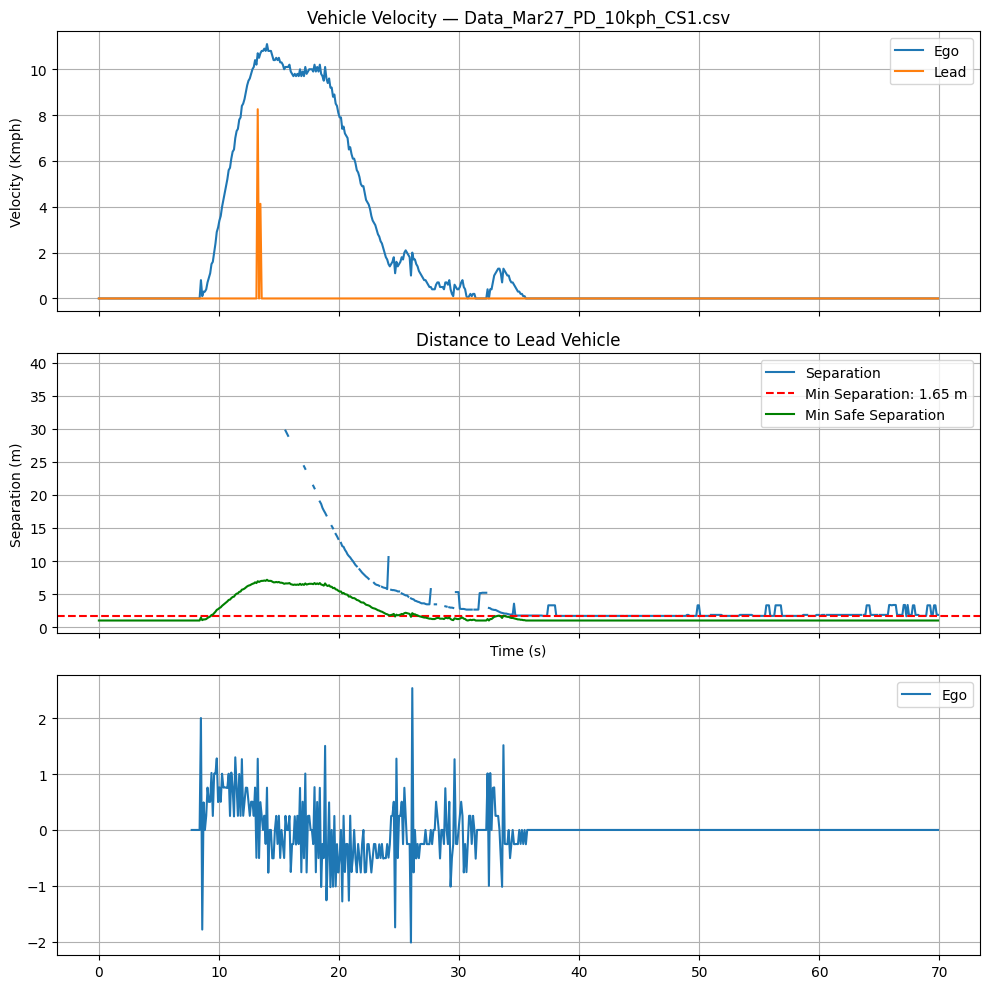

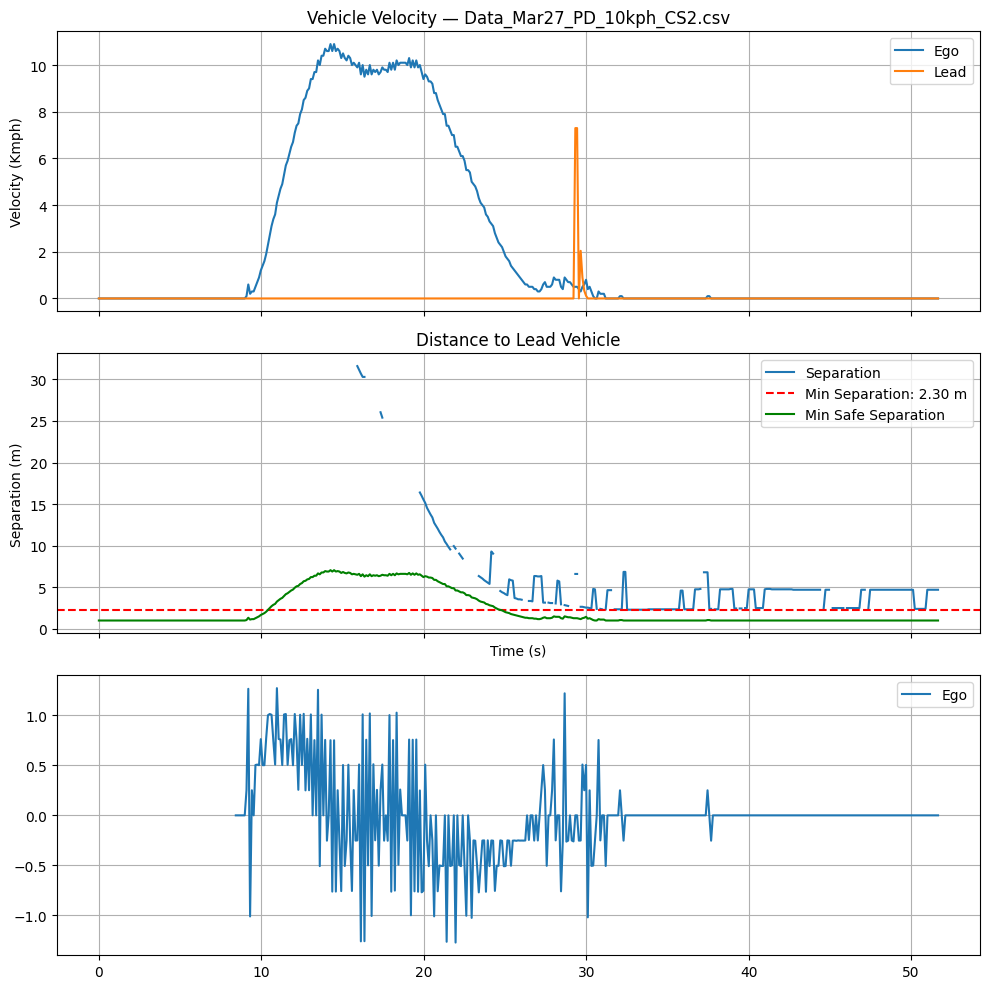

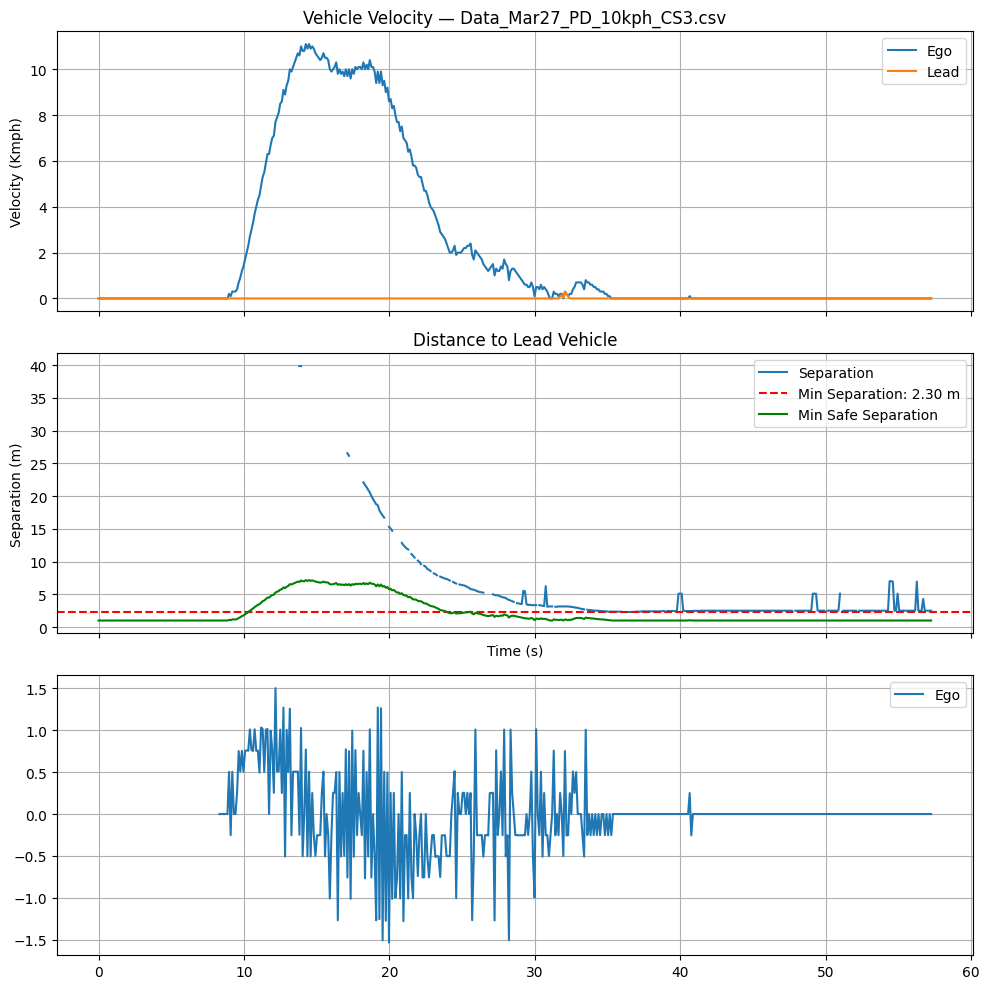

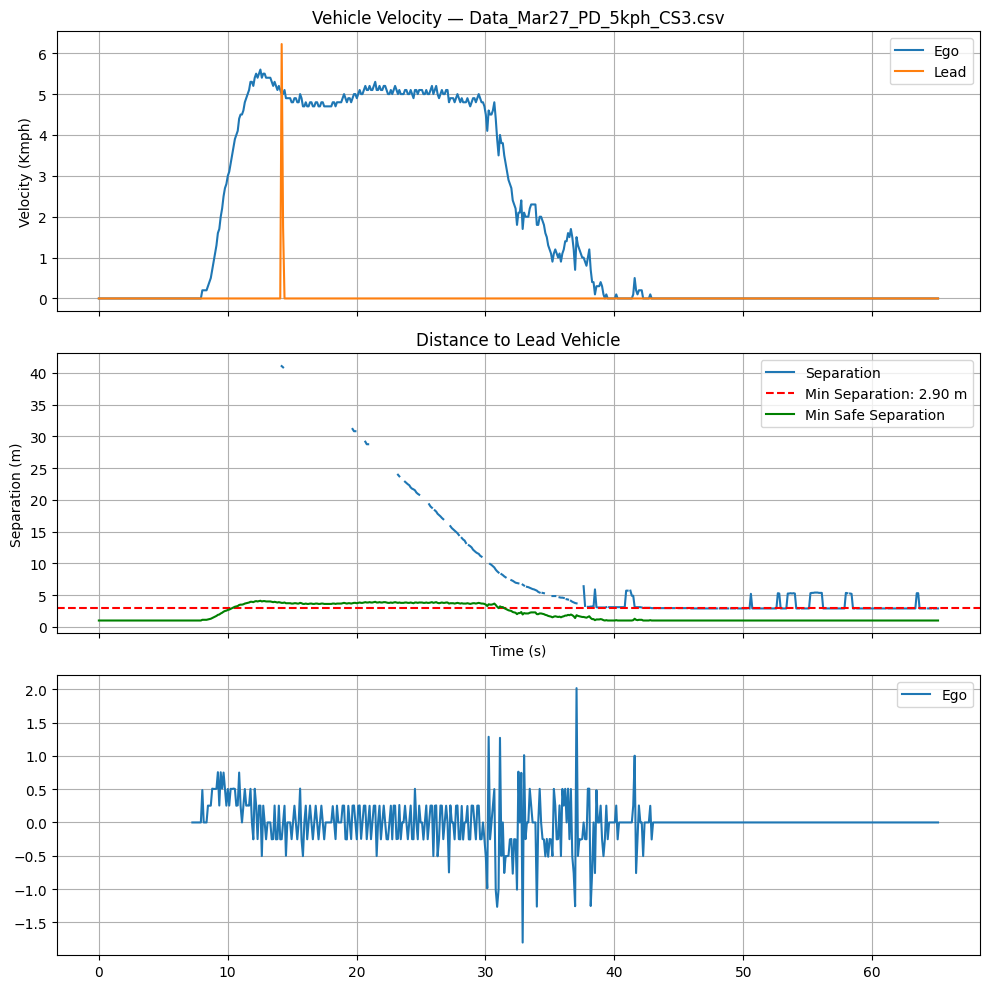

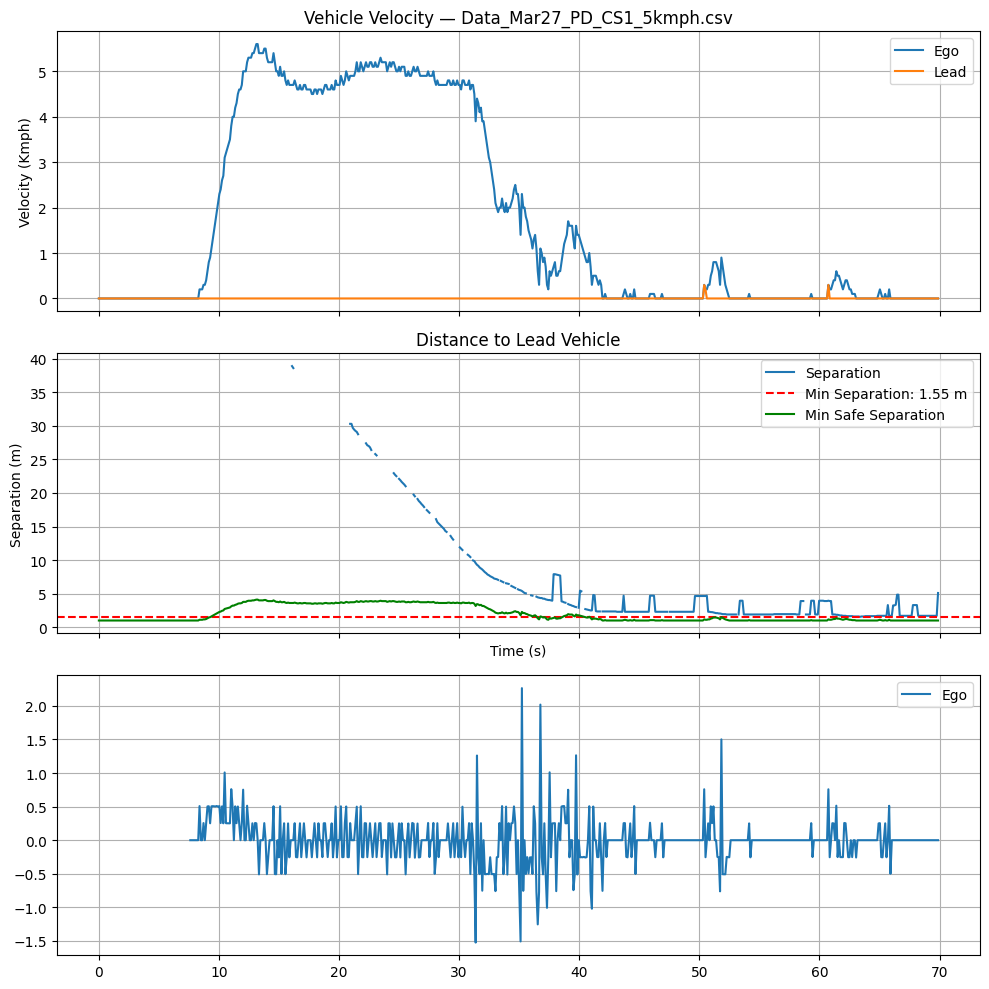

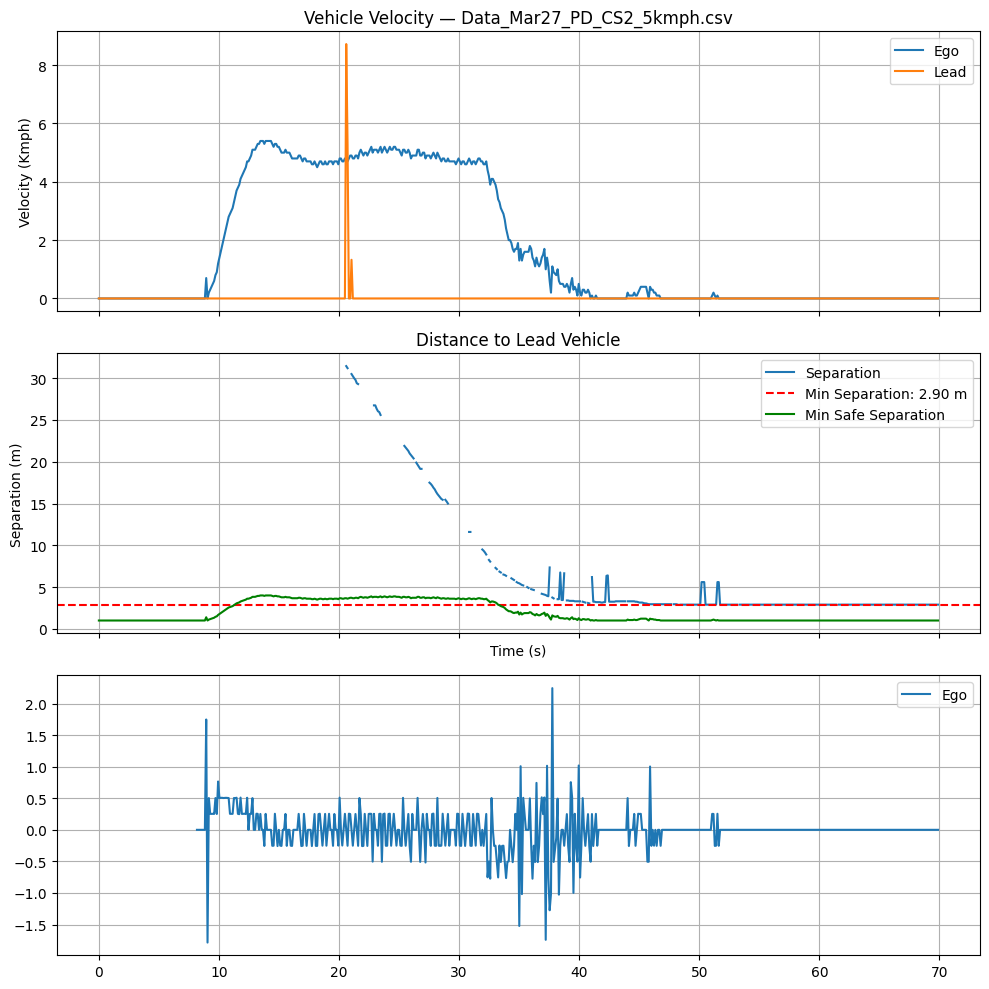

In [16]:
for file, df in data.items():
    fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

    # ---- Velocity ----
    axes[0].plot(df["Time"], df["Ego_Velocity_kmph"], label="Ego")
    if "Obs_Velocity_kmph" in df.columns:
        axes[0].plot(df["Time"], df["Obs_Velocity_kmph"], linestyle="-", label="Lead")

    # ---- Separation ----
    min_sep = df["Separation(m)"].min() if "Separation(m)" in df.columns else None
    if "Separation(m)" in df.columns:
        axes[1].plot(df["Time"], df["Separation(m)"], label="Separation")
        if min_sep is not None:
            axes[1].axhline(y=min_sep, color="red", linestyle="--", label=f"Min Separation: {min_sep:.2f} m")


    # Minimum safe separation line ( 2 seconds at current speed + min safe distance)
    if "Ego_Velocity_kmph" in df.columns:
        min_sep = df["Ego_Velocity_kmph"] * (1000/3600) * 2 + 1  # 2 seconds gap in meters + min safe distance
        axes[1].plot(df["Time"], min_sep, linestyle="-", color="green", label="Min Safe Separation")

    # ---- Acceleration ----
    if "Ego_Acceleration(m/s^2)" in df.columns:
        axes[2].plot(df["Time"], df["Ego_Acceleration(m/s^2)"], label="Ego")
    # if "Obs_Acceleration(m/s^2)" in df.columns:
    #     axes[2].plot(df["Time"], df["Obs_Acceleration(m/s^2)"], label="Lead")

    axes[0].set_ylabel("Velocity (Kmph)")
    axes[0].set_title(f"Vehicle Velocity — {file}")

    axes[1].set_ylabel("Separation (m)")
    axes[1].set_xlabel("Time (s)")
    axes[1].set_title("Distance to Lead Vehicle")

    for ax in axes:
        ax.grid()
        ax.legend()

    plt.tight_layout()
    plt.show()

In [17]:
def clean_velocity_series(v,
                          min_val=0.0,
                          max_val=10.0,          # adjust for your vehicle
                          max_jump=1.0,         # km/h per sample
                          interp_limit=5,
                          rolling_window=5):
    v = pd.to_numeric(v, errors="coerce")
    v.loc[v > 100] = 0.0           # drop garbage high spikes on stop
    v = v.clip(lower=min_val, upper=max_val)
    dv = v.diff().abs()
    v.loc[dv > max_jump] = np.nan # remove spikes
    v = v.interpolate(method="linear", limit=interp_limit, limit_direction="both") # fill short gaps
    v = v.rolling(window=rolling_window, center=True, min_periods=1).median() # smooth
    return v

def clean_separation_series(s,
                            min_val=1.0,
                            max_val=35.0,
                            max_delta=0.1,         # m per sample
                            interp_limit=10,
                            rolling_window=5):
    s = pd.to_numeric(s, errors="coerce").clip(lower=min_val, upper=max_val)
    ds = s.diff().abs()
    s.loc[ds > max_delta] = np.nan
    s = s.interpolate(method="linear", limit=interp_limit, limit_direction="both")
    s = s.rolling(window=rolling_window, center=True, min_periods=1).median()
    return s

## For Stationary Obstacle

In [18]:
for file, df in data.items():
    # Clean raw velocity
    df["Ego_Velocity_clean"] = clean_velocity_series(df["Ego_Velocity_kmph"],
                                                     min_val=0.0, max_val=15.0, max_jump=0.2)
    if "Obs_Velocity_kmph" in df.columns:
        df["Obs_Velocity_clean"] = clean_velocity_series(df["Obs_Velocity_kmph"],
                                                         min_val=-0.1, max_val=0.1, max_jump=0.14)
    else:
        df["Obs_Velocity_clean"] = np.nan

    # Clean separation
    if "Separation(m)" in df.columns:
        df["Separation_clean"] = clean_separation_series(df["Separation(m)"])
    else:
        df["Separation_clean"] = np.nan

    # Recompute Ego position from clean ego velocity
    dt = df["Time"].diff().fillna(0)
    df["Ego_Position_clean"] = (df["Ego_Velocity_clean"].fillna(0) / 3.6) * dt
    df["Ego_Position_clean"] = df["Ego_Position_clean"].cumsum()
    if "Ego_Position(m)" in df.columns:
        df["Ego_Position_clean"] += df["Ego_Position(m)"].iloc[0]

    # Recompute Obs position via separation
    df["Obs_Position_clean"] = df["Ego_Position_clean"] + df["Separation_clean"]

    # Optionally, nothing is dropped: persist all intermediate
    data[file] = df

In [19]:
alpha = 0.9
for file, df in data.items():
    prev_obs_vel = np.nan  # start with NaN
    prev_obs_pos = np.nan
    prev_sep = np.nan

    for i in range(len(df)):
        obs_vel_r = df.loc[i, "Obs_Velocity_clean"]
        obs_pos_r = df.loc[i, "Obs_Position_clean"]
        ego_pos_i = df.loc[i, "Ego_Position_clean"]

        # ---- Low-pass only if current value exists ----
        if pd.notna(obs_vel_r) and pd.notna(prev_obs_vel):
            obs_vel_f = alpha * prev_obs_vel + (1 - alpha) * obs_vel_r
        else:
            obs_vel_f = obs_vel_r  # use raw if missing or first sample

        # ---- Position handling (rest unchanged) ----
        if np.isnan(obs_pos_r):
            obs_pos_f = prev_obs_pos
        else:
            obs_pos_f = obs_pos_r

        if pd.notna(prev_obs_pos) and pd.notna(obs_pos_f) and abs(obs_pos_f - prev_obs_pos) > 5:
            obs_pos_f = prev_obs_pos

        sep = obs_pos_f - ego_pos_i
        if pd.notna(prev_sep) and abs(sep - prev_sep) > 2:
            obs_pos_f = prev_obs_pos
            sep = obs_pos_f - ego_pos_i

         # ---- New logic: For stationary obstacle, reject any increase in separation ----
        if pd.notna(prev_sep) and pd.notna(sep) and sep > prev_sep:
            sep = prev_sep #- 0.001  # small buffer to allow for minor noise
            obs_pos_f = ego_pos_i + sep  # Adjust obs position to match the propagated separation

        df.at[i, "Obs_Velocity_clean"] = obs_vel_f
        df.at[i, "Obs_Position_clean"] = obs_pos_f
        df.at[i, "Separation_clean"] = sep

        prev_obs_vel = obs_vel_f
        prev_obs_pos = obs_pos_f
        prev_sep = sep

### Saving the cleaned data to new folder for further use.

In [20]:
output_folder = script_dir / "Processed_Data_March27_PD"
output_folder.mkdir(exist_ok=True)  
for file, df in data.items():
    output_path = output_folder / file
    df.to_csv(output_path, index=False)
    print(f"Saved cleaned data to {output_path}")

Saved cleaned data to C:\Users\home\Desktop\ACC\Auto-Cruise\Adaptive-Cruise-Control\Adaptive-Cruise-Control\9_Vehicle_Testing_Results\Testing_Using_Radar\March27_2026\Processed_Data_March27_PD\Data_Mar27_PD_10kph_CS1.csv
Saved cleaned data to C:\Users\home\Desktop\ACC\Auto-Cruise\Adaptive-Cruise-Control\Adaptive-Cruise-Control\9_Vehicle_Testing_Results\Testing_Using_Radar\March27_2026\Processed_Data_March27_PD\Data_Mar27_PD_10kph_CS2.csv
Saved cleaned data to C:\Users\home\Desktop\ACC\Auto-Cruise\Adaptive-Cruise-Control\Adaptive-Cruise-Control\9_Vehicle_Testing_Results\Testing_Using_Radar\March27_2026\Processed_Data_March27_PD\Data_Mar27_PD_10kph_CS3.csv
Saved cleaned data to C:\Users\home\Desktop\ACC\Auto-Cruise\Adaptive-Cruise-Control\Adaptive-Cruise-Control\9_Vehicle_Testing_Results\Testing_Using_Radar\March27_2026\Processed_Data_March27_PD\Data_Mar27_PD_5kph_CS3.csv
Saved cleaned data to C:\Users\home\Desktop\ACC\Auto-Cruise\Adaptive-Cruise-Control\Adaptive-Cruise-Control\9_Vehicle

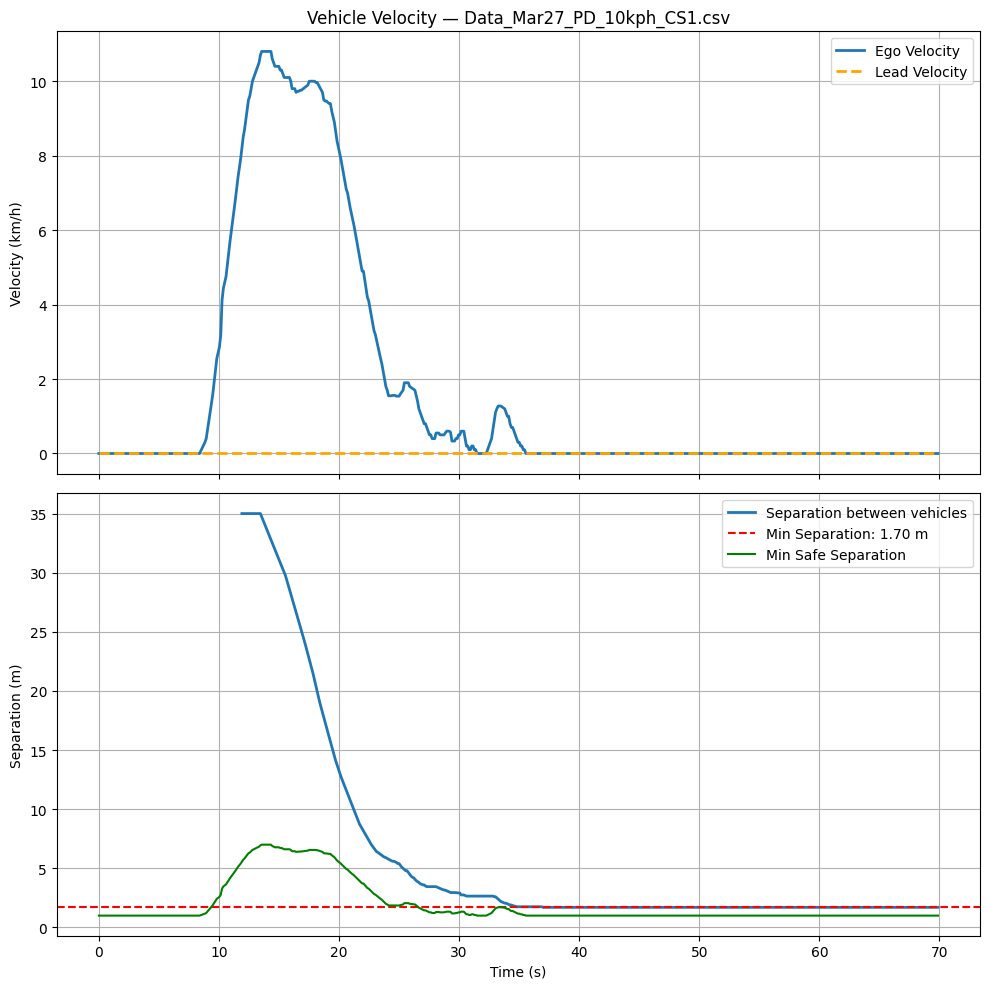

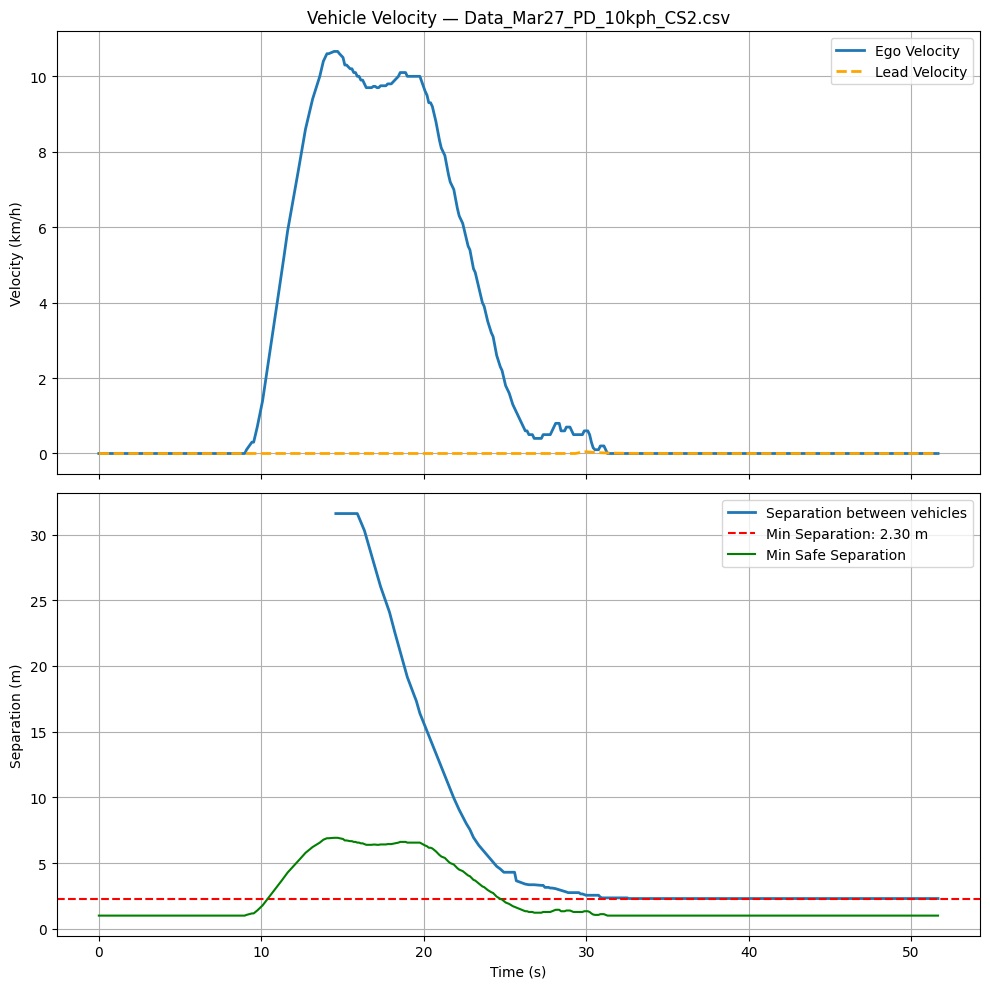

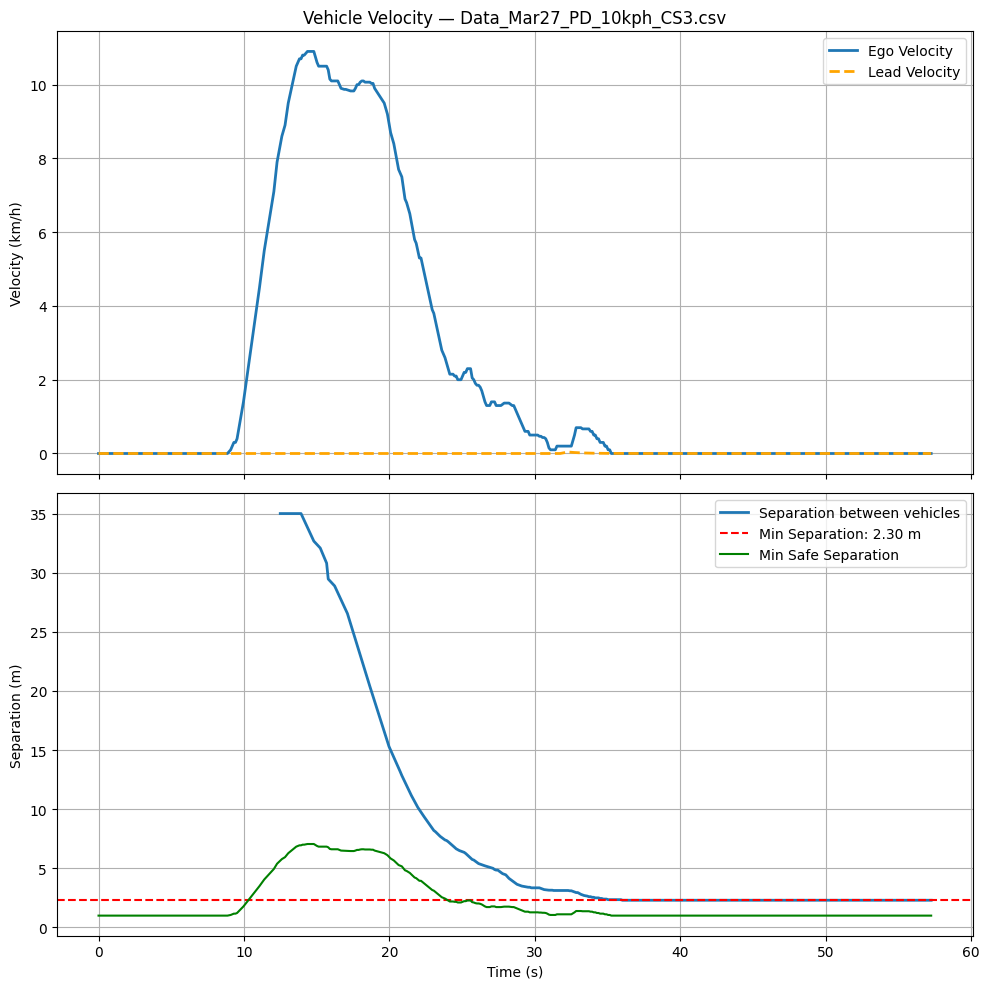

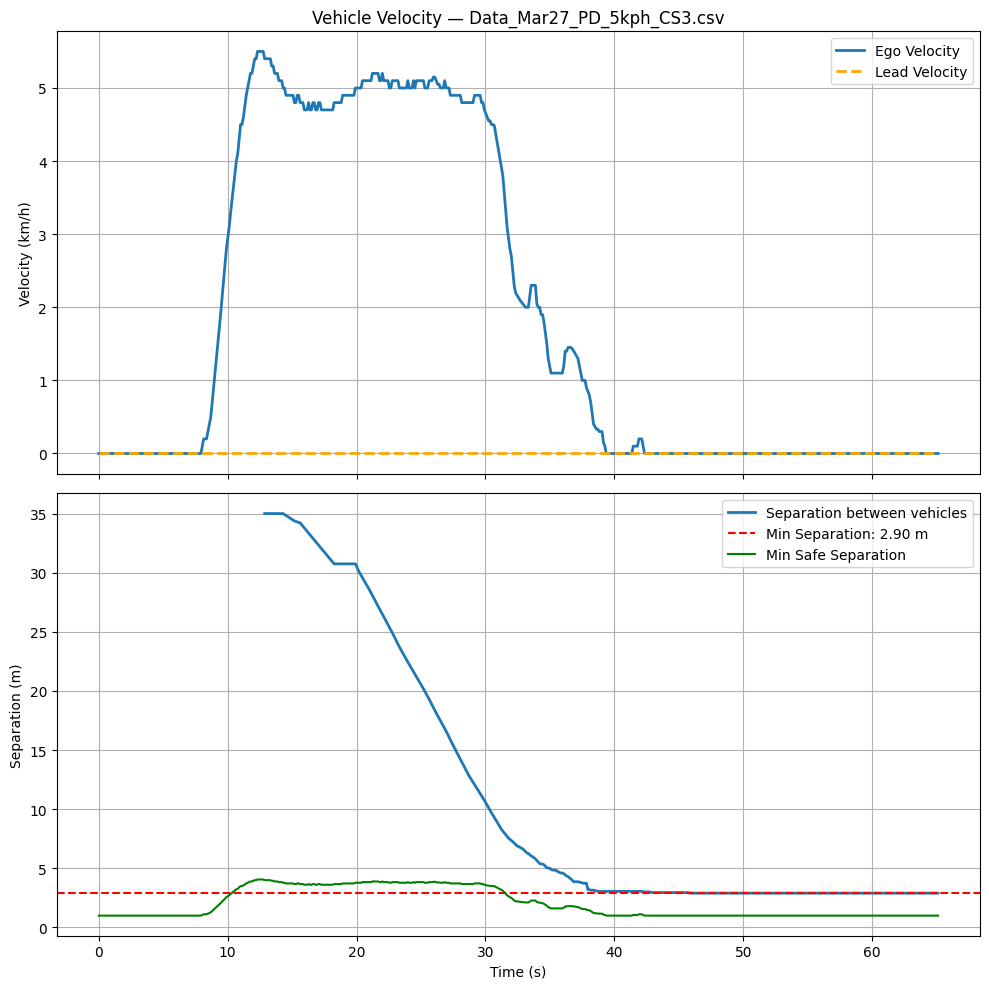

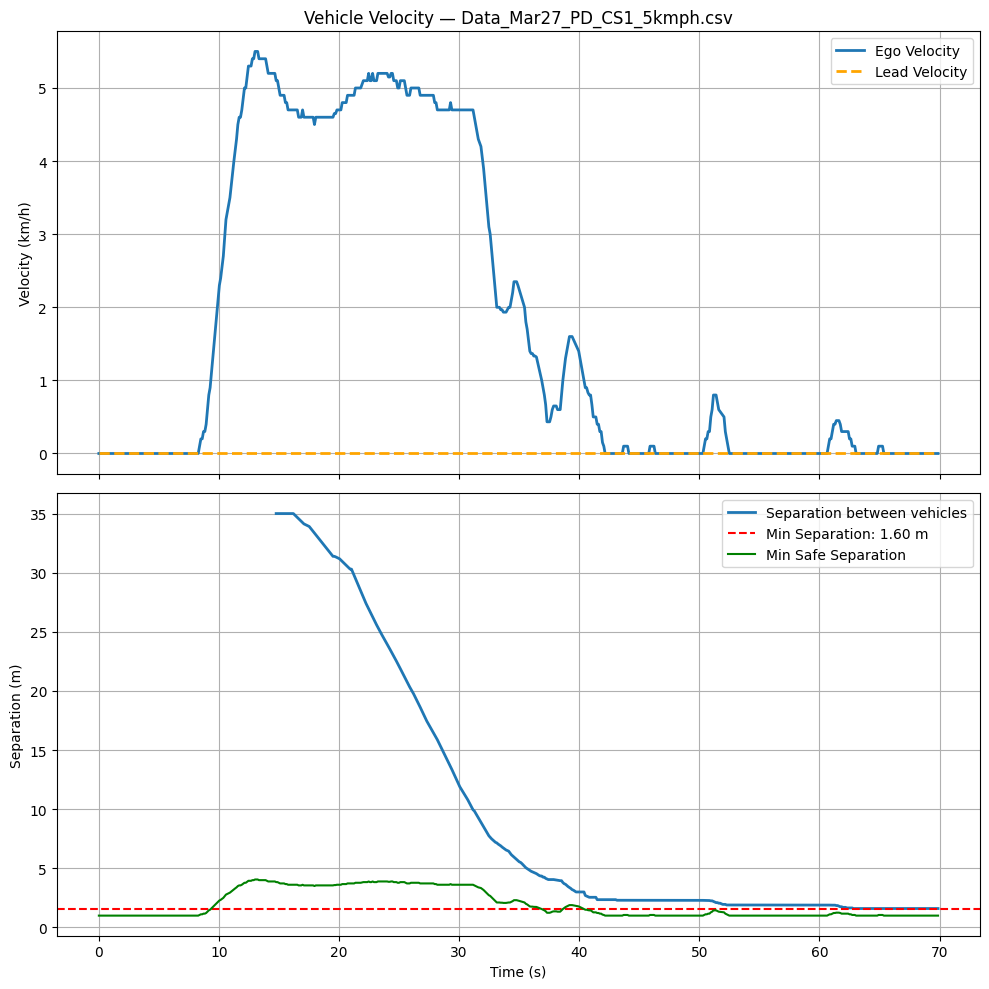

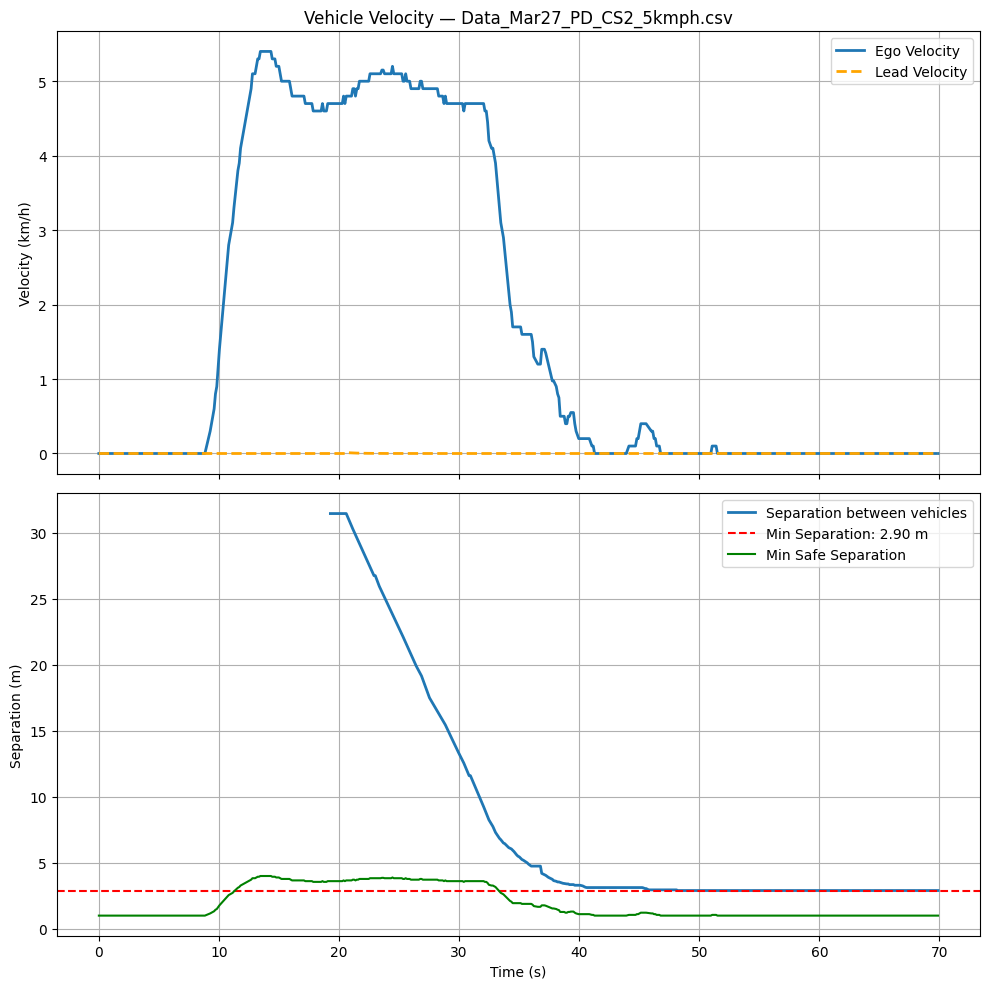

In [ ]:
for file, df in data.items():
    fig, axes = plt.subplots(2,1,figsize=(10,10), sharex=True)

    axes[0].plot(df["Time"], df["Ego_Velocity_clean"], label="Ego Velocity", linewidth=2)
    # axes[0].plot(df["Time"], df["Ego_Velocity_kmph"], alpha=0.3, label="Ego raw")
    if "Obs_Velocity_clean" in df.columns:
        axes[0].plot(df["Time"], df["Obs_Velocity_clean"], color="orange",linewidth=2, linestyle='--', label="Lead Velocity")
    axes[0].set_ylabel("Velocity (km/h)")
    axes[0].set_title(f"Vehicle Velocity — {file}")
    axes[0].legend()
    axes[0].grid()

    axes[1].plot(df["Time"], df["Separation_clean"], label="Separation between vehicles", linewidth=2)
    minimum_separation = df["Separation_clean"].min()
    axes[1].axhline(minimum_separation, color='red', linestyle='--', label=f'Min Separation: {minimum_separation:.2f} m')
    axes[1].set_ylabel("Separation (m)")
    axes[1].set_xlabel("Time (s)")
    axes[1].legend()
    axes[1].grid()

    # Minimum separation line ( 2 seconds at current speed + min safe distance)
    if "Ego_Velocity_clean" in df.columns:
        min_sep = df["Ego_Velocity_clean"] * (1000/3600) * 2 + 1  # 2 seconds gap in meters + min safe distance
        axes[1].plot(df["Time"], min_sep, linestyle="-", color="green", label="Min Safe Separation")
        axes[1].legend()

    plt.tight_layout()
    plt.show()

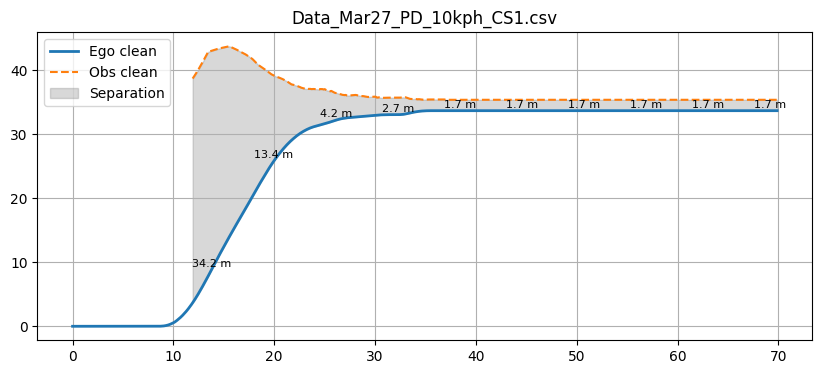

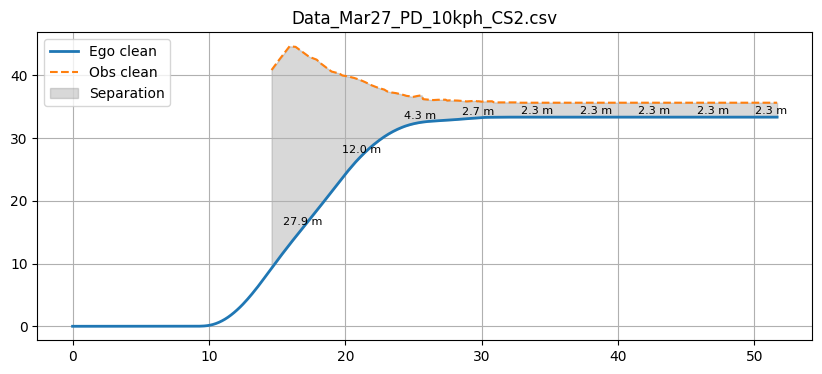

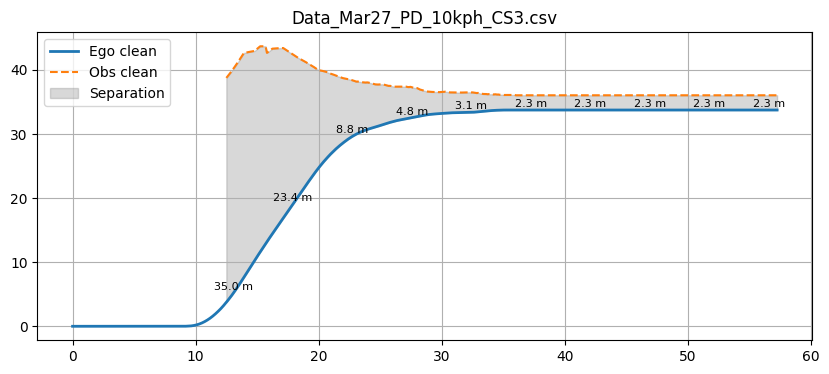

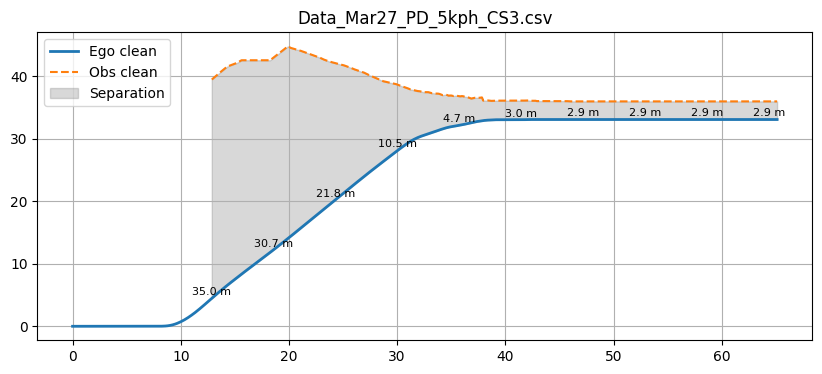

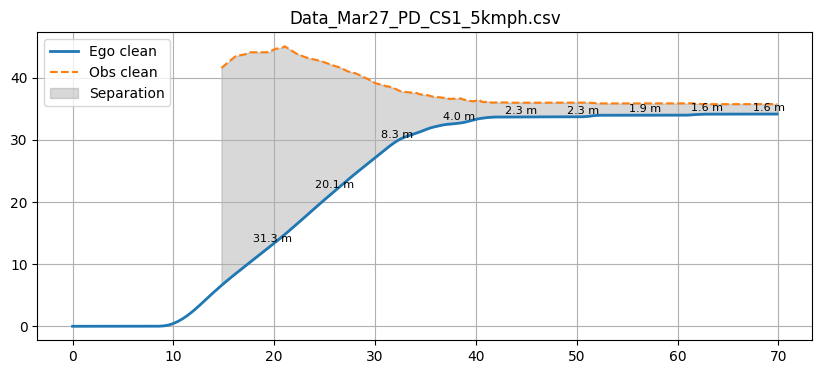

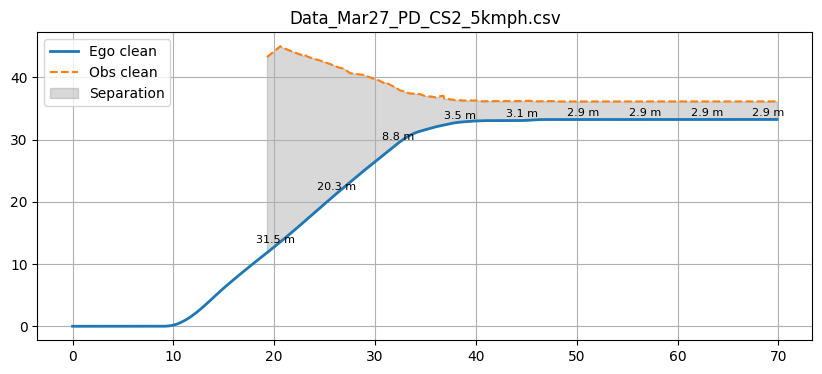

In [22]:
for file, df in data.items():
    plt.figure(figsize=(10,4))
    # plt.plot(df["Time"], df["Ego_Position(m)"], alpha=0.3, label="Ego raw")
    plt.plot(df["Time"], df["Ego_Position_clean"], label="Ego clean", linewidth=2)
    plt.plot(df["Time"], df["Obs_Position_clean"], label="Obs clean", linestyle="--")
    #show the gap between ego and obs as separation and show the value of separation as well
    plt.fill_between(df["Time"], df["Ego_Position_clean"], df["Obs_Position_clean"], color="gray", alpha=0.3, label="Separation")
    # Show the value of separation as text on the plot
    for i in range(0, len(df), max(1, len(df)//10)):  # Show text for up to 10 points
        if pd.notna(df.loc[i, "Separation_clean"]):
            plt.text(df.loc[i, "Time"], df.loc[i, "Ego_Position_clean"] + 0.5, f"{df.loc[i, 'Separation_clean']:.1f} m", fontsize=8, ha='center')       


    plt.legend(); plt.grid(); plt.title(file); plt.show()